#### 0. Importar librerias

In [79]:
import pandas as pd
import sklearn
import missingno as mo
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, f1_score
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier


#### 1. Cargar e inspeccionar los datos

In [4]:
df = pd.read_csv('Datos/Transformados/df_final_para_regresion.csv')

C:\Users\Uxue Duran Nuño\AppData\Local\Temp\ipykernel_15164\924406895.py:1: DtypeWarning: Columns (56) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Datos/Transformados/df_final_para_regresion.csv')


In [5]:
df.head()

,booked_at,checkin_time,checkout_time,lead_time,lenght_of_stay,checkin_month,checkin_day,adult_count,child_count,origin,...,hrMedia,hrMax,horaHrMax,hrMin,horaHrMin,cluster,cluster_0,cluster_1,cluster_2,cluster_3
0,2022-11-26 16:10:00,2023-01-01,2023-01-02 12:00:00,36,1,January,Sunday,1,0,channel_manager,...,30.0,98.0,23:59,27.0,Varias,2,0,0,1,0
1,2022-12-21 17:27:00,2023-01-01,2023-01-10 12:00:00,11,9,January,Sunday,1,0,channel_manager,...,30.0,98.0,23:59,27.0,Varias,2,0,0,1,0
2,2022-09-21 19:46:00,2023-01-01,2023-01-07 12:00:00,102,6,January,Sunday,2,4,channel_manager,...,30.0,98.0,23:59,27.0,Varias,2,0,0,1,0
3,2022-09-24 12:09:00,2023-01-01,2023-01-02 12:00:00,99,1,January,Sunday,2,2,channel_manager,...,30.0,98.0,23:59,27.0,Varias,2,0,0,1,0
4,2022-10-18 07:12:00,2023-01-01,2023-01-02 12:00:00,75,1,January,Sunday,4,0,channel_manager,...,30.0,98.0,23:59,27.0,Varias,2,0,0,1,0


In [6]:
df.columns

Index(['booked_at', 'checkin_time', 'checkout_time', 'lead_time',
       'lenght_of_stay', 'checkin_month', 'checkin_day', 'adult_count',
       'child_count', 'origin', 'travel_agency_name', 'requested_category',
       'requested_category_name', 'asset', 'asset_type', 'brand',
       'asset_opening_date', 'available_units', 'business_segment', 'rate',
       'rate_group_name', 'rate_type', 'completed_entry_forms_count',
       'all_entry_forms_completed', 'last_entry_form_completed_at',
       'returning_inhabitant', 'recurrence', 'libere_community',
       'bought_products', 'product_count', 'reservation_net_value',
       'total_adr', 'status', 'cancelled_at', 'cancellation_reason',
       'cancellation_lead_time', 'ciudad', 'mes_cancelacion',
       'estacion_cancelacion', 'mes_estancia', 'estacion_estancia',
       'mes_reserva', 'estacion_reserva', 'dia_semana_reserva',
       'dia_semana_reserva_nombre', 'dia_semana_cancelacion',
       'dia_semana_cancelacion_nombre', 'dia_sem

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52004 entries, 0 to 52003
Data columns (total 87 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   booked_at                       52004 non-null  object 
 1   checkin_time                    52004 non-null  object 
 2   checkout_time                   52004 non-null  object 
 3   lead_time                       52004 non-null  int64  
 4   lenght_of_stay                  52004 non-null  int64  
 5   checkin_month                   52004 non-null  object 
 6   checkin_day                     52004 non-null  object 
 7   adult_count                     52004 non-null  int64  
 8   child_count                     52004 non-null  int64  
 9   origin                          52004 non-null  object 
 10  travel_agency_name              52004 non-null  object 
 11  requested_category              52004 non-null  object 
 12  requested_category_name         

In [8]:
df.shape

(52004, 87)

<Axes: >

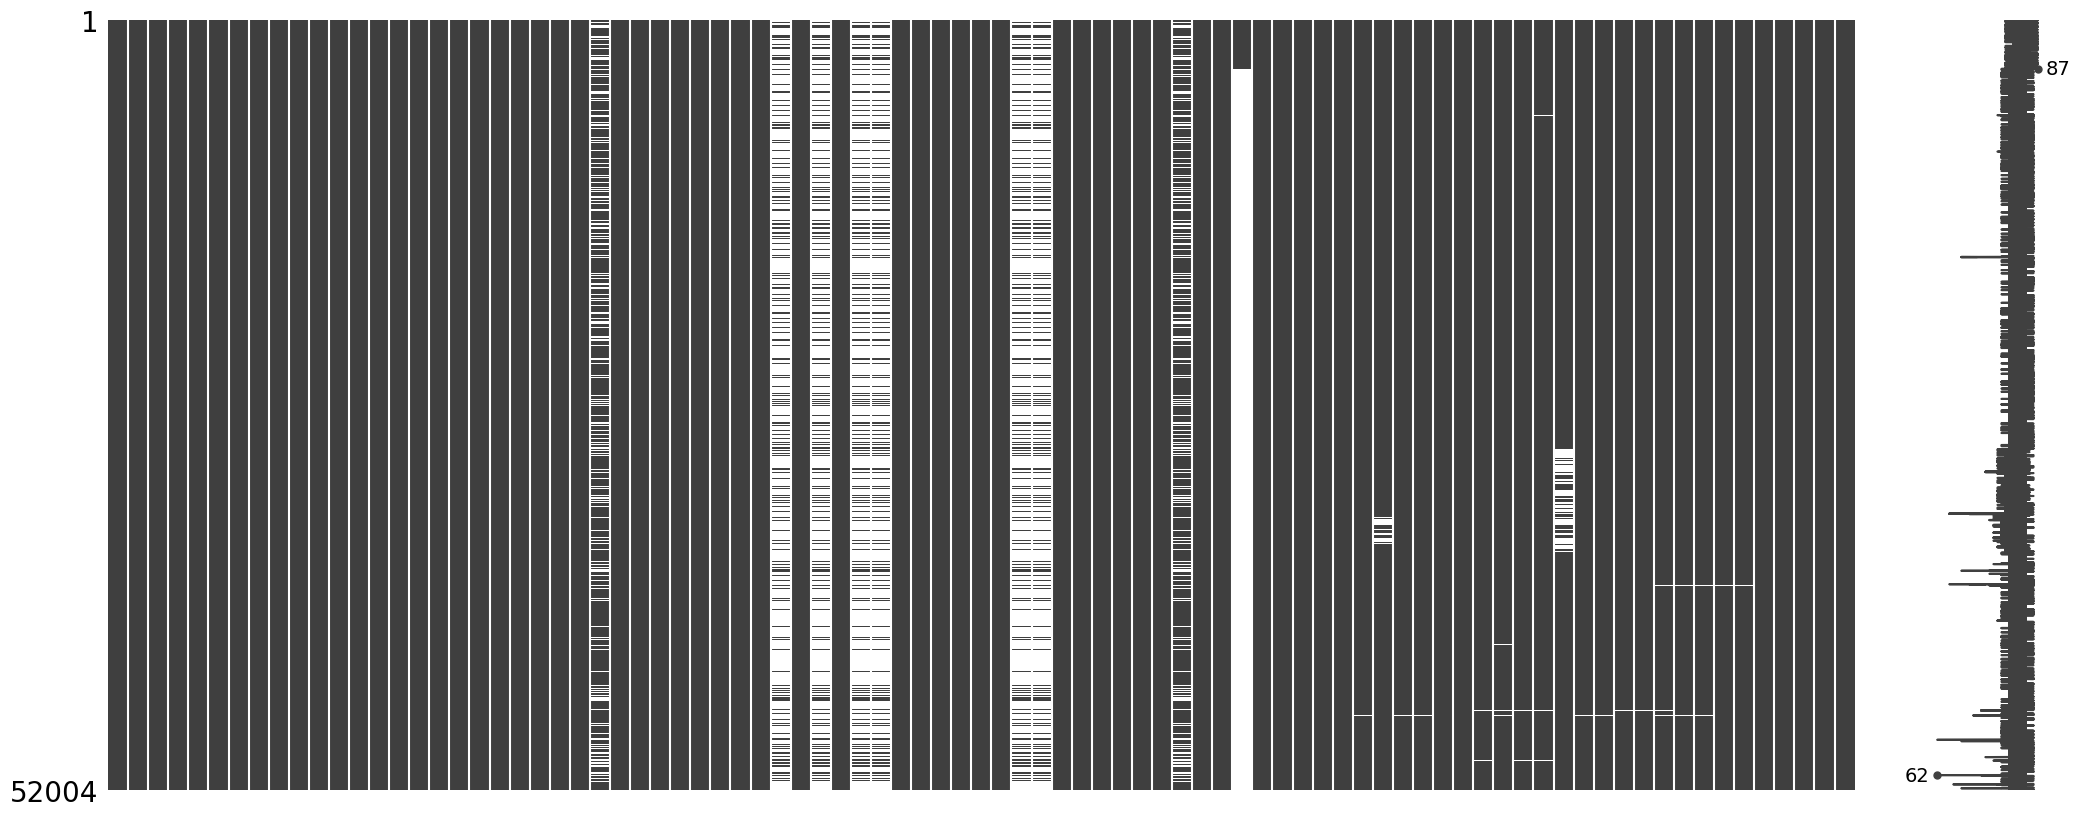

In [9]:
mo.matrix(df)

#### 2. Seleccion de variables relevantes para modelado

In [10]:
# Criterio para la seleccion de variables para regresion:
#    1. Primero se seleccionan únicamente variables disponibles en el momento de la reserva y que, desde el punto de vista de negocio, puedan influir en la probabilidad de cancelación.
#    2. Después mirar la relacion entre cada una de ellas con el target:
#       - para las numericas con corr
#       - para las binarias media del target
#       - para las categoricas la tasa de cancelacion por grupo (si se acaba seleccionando pasar a dummies)
#    3. Entre las seleccionadas, eliminar las que tengan alta correlacion entre ellas

In [11]:
# Definir el target
df['target'] = (df['status'] == 'cancelled').astype(int)

df['target'].value_counts(normalize=True) # 76% no cancelan

target
0    0.764018
1    0.235982
Name: proportion, dtype: float64

In [12]:
# 1. Seleccion conceptual
vars_numericas = ['lead_time', 'lenght_of_stay', 
                  'adult_count', 'child_count',
                  'available_units', 'reservation_net_value', 
                  'total_adr', 'product_count', 
                  'recurrence', 'ratio_cancelacion_mes_estancia', 
                  'tmed', 'prec', 'sol']

vars_binarias = ['zona_roja','es_finde',
                 'es_festivo', 'cluster_1',
                 'cluster_2', 'cluster_3']

vars_categoricas = ['origin', 'business_segment',
                    'rate_type', 'requested_category', 
                    'asset_type', 'brand', 'ciudad']

In [13]:
#2. Analisis de relacion con el target

# 2.1 Numericas
corr_num = (
    df[vars_numericas + ['target']]
    .corr()['target']
    .sort_values(ascending=False)
    .drop('target'))

print(corr_num)


lead_time                         0.220967
lenght_of_stay                    0.131798
adult_count                       0.101525
reservation_net_value             0.086955
total_adr                         0.053947
ratio_cancelacion_mes_estancia    0.025349
prec                              0.014982
child_count                      -0.006512
available_units                  -0.012650
sol                              -0.021953
tmed                             -0.026100
recurrence                       -0.046127
product_count                    -0.135070
Name: target, dtype: float64


In [14]:
# Nos quedamos con |corr| >= 0.05 y 1, porque aun que sean correlaciones debiles, al tratarse de cancelaciones y de comportamiento humano,
# 0.10 ya es bastante y 0.05 puede ser útil combinado con otras variables
vars_numericas_filtradas = corr_num[corr_num.abs() >= 0.05].index.tolist()
print(vars_numericas_filtradas)

['lead_time', 'lenght_of_stay', 'adult_count', 'reservation_net_value', 'total_adr', 'product_count']


In [15]:
# Mirar si hay alta correlacion entre las numericas (para evitar multicolinealidad)
print(df[vars_numericas_filtradas].corr()) # Ninguna supera un valor critico (~0.7), asi que no eliminamos ninguna

                       lead_time  lenght_of_stay  adult_count  \
lead_time               1.000000        0.098732     0.220131   
lenght_of_stay          0.098732        1.000000    -0.030339   
adult_count             0.220131       -0.030339     1.000000   
reservation_net_value   0.176664        0.448822     0.330383   
total_adr               0.134558       -0.078498     0.526133   
product_count           0.105714        0.121244     0.032290   

                       reservation_net_value  total_adr  product_count  
lead_time                           0.176664   0.134558       0.105714  
lenght_of_stay                      0.448822  -0.078498       0.121244  
adult_count                         0.330383   0.526133       0.032290  
reservation_net_value               1.000000   0.626397       0.307983  
total_adr                           0.626397   1.000000       0.190920  
product_count                       0.307983   0.190920       1.000000  


In [16]:
# 2.2 Binarias
for var in vars_binarias:
    print(f'\n{var}')
    print(df.groupby(var)['target'].mean())


zona_roja
zona_roja
0    0.230250
1    0.249437
Name: target, dtype: float64

es_finde
es_finde
0    0.229869
1    0.251552
Name: target, dtype: float64

es_festivo
es_festivo
0    0.236251
1    0.227094
Name: target, dtype: float64

cluster_1
cluster_1
0    0.245429
1    0.196279
Name: target, dtype: float64

cluster_2
cluster_2
0    0.230342
1    0.259020
Name: target, dtype: float64

cluster_3
cluster_3
0    0.232667
1    0.241563
Name: target, dtype: float64


In [17]:
# Para las variables binarias un umbral razonable de diferencia puede ser mayor que 0.02
vars_binarias_filtradas = []

for var in vars_binarias:
    medias = df.groupby(var)['target'].mean()
    diff = abs(medias[1] - medias[0])
    if diff > 0.02:
        vars_binarias_filtradas.append(var)

print(vars_binarias_filtradas)

['es_finde', 'cluster_1', 'cluster_2']


In [18]:
# 2.3 Categoricas
for var in vars_categoricas:
    print(f'\n{var}')
    display(
        df.groupby(var)['target']
        .mean()
        .sort_values(ascending=False)
        .head(10))


origin


origin
email              0.420612
telephone          0.302963
in_person          0.301370
channel_manager    0.240168
direct_channel     0.136554
Name: target, dtype: float64


business_segment


business_segment
Travel Individual      0.474332
Business Individual    0.440613
Mid Stay               0.365385
Travel Group           0.342903
MICE Group             0.321063
MICE Individual        0.276471
Leisure Group          0.236181
Leisure Individual     0.219563
Business Group         0.149533
Name: target, dtype: float64


rate_type


...

asset_type
apartment     0.241563
aparthotel    0.240264
hostel        0.228008
Name: target, dtype: float64


brand


brand
koisi     0.259020
libere    0.230342
Name: target, dtype: float64


ciudad


ciudad
Valencia    0.285312
Granada     0.271475
Donosti     0.259020
Bilbao      0.253384
Vitoria     0.240264
Madrid      0.227432
Pamplona    0.219519
Málaga      0.217810
Córdoba     0.196279
Name: target, dtype: float64

In [19]:
vars_categoricas_filtradas = []

for var in vars_categoricas:
    medias = df.groupby(var)['target'].mean()
    diff = medias.max() - medias.min()
    if diff >= 0.03:
        vars_categoricas_filtradas.append(var)

print(vars_categoricas_filtradas) 


['origin', 'business_segment', 'rate_type', 'requested_category', 'ciudad']


In [41]:
# Crear el df para modelado con las variables seleccionadas
df_modelo = df[vars_numericas_filtradas + vars_binarias_filtradas + vars_categoricas_filtradas + ['target']]

df_modelo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52004 entries, 0 to 52003
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   lead_time              52004 non-null  int64  
 1   lenght_of_stay         52004 non-null  int64  
 2   adult_count            52004 non-null  int64  
 3   reservation_net_value  52004 non-null  float64
 4   total_adr              52004 non-null  float64
 5   product_count          52004 non-null  int64  
 6   es_finde               52004 non-null  int64  
 7   cluster_1              52004 non-null  int64  
 8   cluster_2              52004 non-null  int64  
 9   origin                 52004 non-null  object 
 10  business_segment       52004 non-null  object 
 11  rate_type              52004 non-null  object 
 12  requested_category     52004 non-null  object 
 13  ciudad                 52004 non-null  object 
 14  target                 52004 non-null  int64  
dtypes:

In [42]:
# Ahora dummificar las variables categoricas seleccionadas
df_modelo = pd.get_dummies(df_modelo, columns=vars_categoricas_filtradas, drop_first=True)

df_modelo.columns

Index(['lead_time', 'lenght_of_stay', 'adult_count', 'reservation_net_value',
       'total_adr', 'product_count', 'es_finde', 'cluster_1', 'cluster_2',
       'target', 'origin_direct_channel', 'origin_email', 'origin_in_person',
       'origin_telephone', 'business_segment_Business Individual',
       'business_segment_Leisure Group', 'business_segment_Leisure Individual',
       'business_segment_MICE Group', 'business_segment_MICE Individual',
       'business_segment_Mid Stay', 'business_segment_Travel Group',
       'business_segment_Travel Individual', 'rate_type_Mid Stay',
       'rate_type_Non Refundable', 'requested_category_Hostel room',
       'requested_category_One bedroom apartment',
       'requested_category_One bedroom apartment superior',
       'requested_category_Studio', 'requested_category_Studio superior',
       'requested_category_Three bedroom apartment',
       'requested_category_Three bedroom apartment superior',
       'requested_category_Two bedroom apar

#### 3. Separar train / test

In [43]:
# Primero separar X (variables explicativas) e Y (target)
X = df_modelo.drop(columns='target')
Y = df_modelo['target']

# Separar train y test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42, stratify=Y) # stratify=Y asegura que train y test tengan la misma propocion de clases que el df original, importante porque el target esta desbalanceado (76% no cancelan)

# # Aplicar SMOTE solo al conjunto de entrenamiento
# smote = SMOTE(random_state=42)
# X_train_res, y_train_res = smote.fit_resample(X_train, Y_train)

# Ver tamaño antes y después
# print("Antes:", Y_train.value_counts())
# print("Después:", pd.Series(y_train_res).value_counts())

#### 4. Escalar las variables

In [44]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### 5. Entrenar modelo de Regresión Logística

In [45]:
modelo_reg_log = LogisticRegression(max_iter=1000, class_weight='balanced', penalty='l2', solver='liblinear')
modelo_reg_log.fit(X_train_scaled, Y_train)

c:\conda_envs\reto06_VerdeOscuro\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

#### 6. Evaluación del modelo

In [46]:
y_pred = modelo_reg_log.predict(X_test_scaled)
y_prob = modelo_reg_log.predict_proba(X_test_scaled)[:, 1]

print(classification_report(Y_test, y_pred))
print('------------------------------------------')
print("ROC AUC:", roc_auc_score(Y_test, y_prob))
print('------------------------------------------')
print(confusion_matrix(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.70      0.78     11920
           1       0.42      0.71      0.53      3682

    accuracy                           0.70     15602
   macro avg       0.65      0.71      0.66     15602
weighted avg       0.78      0.70      0.72     15602

------------------------------------------
ROC AUC: 0.7683484797254192
------------------------------------------
[[8313 3607]
 [1050 2632]]


#### 7. Probar StratifiedKFold

In [72]:
# Consiste en dividir los datos en k partes (folds). Luego, entrenas el modelo k veces: cada vez usas k-1 partes para entrenar y la parte restante para probar. Al final, se promedian las métricas de todas las iteraciones.

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # 5 folds

f1_scores = []
roc_scores = []

for train_index, test_index in skf.split(X, Y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = Y.iloc[train_index], Y.iloc[test_index]
    
    # Escalar variables numéricas
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Modelo
    model = LogisticRegression(C = 1,max_iter=1000, class_weight='balanced', l1_ratio=0, solver='saga')
    model.fit(X_train_scaled, y_train)
    
    # Predicciones
    y_prob = model.predict_proba(X_test_scaled)[:,1]
    y_pred = (y_prob >= 0.54).astype(int)
    
    # Métricas
    f1_scores.append(f1_score(y_test, y_pred))
    roc_scores.append(roc_auc_score(y_test, y_prob))

print("F1-score promedio:", np.mean(f1_scores))
print("ROC AUC promedio:", np.mean(roc_scores))

F1-score promedio: 0.5440188625407563
ROC AUC promedio: 0.774115083245208


In [ ]:
# Comprobar cual es el mejor valor de probabilidad
thresholds = np.arange(0.1, 0.9, 0.01)
best_thresh, best_f1 = 0.5, 0

for t in thresholds:
    y_pred_thresh = (y_prob >= t).astype(int)
    f1 = f1_score(y_test, y_pred_thresh)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("Mejor threshold:", best_thresh, "con F1:", best_f1)

Mejor threshold: 0.5399999999999998 con F1: 0.5420783645655878


In [74]:
# Comprobar los mejores hiperparametros para el modeo mediante GridSearch

# Pipeline: Escalado + modelo
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(C=1, max_iter=1000, class_weight='balanced', solver='saga', l1_ratio=1))
])

# Definir grid de hiperparámetros a probar
param_grid = {
    'clf__C': [0.01, 0.1, 1, 10],         # Fuerza de regularización
    'clf__penalty': ['l1', 'l2'],         # Tipo de regularización
    'clf__l1_ratio': [0, 0.5, 1]          # Solo usado con 'elasticnet', saga permite
}

# Stratified K-Fold para mantener proporción de clases
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='f1',            # Métrica para optimizar
    cv=skf,
    n_jobs=-1,               # Usa todos los cores
    verbose=1
)

# Entrenar
grid.fit(X, Y)

# Mejor modelo y mejores hiperparámetros
print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor F1-score CV:", grid.best_score_)


Fitting 5 folds for each of 24 candidates, totalling 120 fits


c:\conda_envs\reto06_VerdeOscuro\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\conda_envs\reto06_VerdeOscuro\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Mejores hiperparámetros: {'clf__C': 0.1, 'clf__l1_ratio': 0, 'clf__penalty': 'l1'}
Mejor F1-score CV: 0.53327782564456


#### 8. Entrenar modelo SVM

In [76]:
f1_scores = []
roc_scores = []

for train_index, test_index in skf.split(X, Y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = Y.iloc[train_index], Y.iloc[test_index]

    # Escalar
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Modelo SVM
    model = SVC(kernel='rbf', C=1, class_weight='balanced', probability=True, random_state=42)
    model.fit(X_train_scaled, y_train)

    # Predicciones
    y_prob = model.predict_proba(X_test_scaled)[:,1]
    y_pred = (y_prob >= 0.5).astype(int)

    # Métricas
    f1_scores.append(f1_score(y_test, y_pred))
    roc_scores.append(roc_auc_score(y_test, y_prob))

print("F1-score promedio:", np.mean(f1_scores))
print("ROC AUC promedio:", np.mean(roc_scores))

F1-score promedio: 0.5266672122587
ROC AUC promedio: 0.8150983950338343


##### 9. Entrenar modelo Naive

In [78]:
# Selección de variables para Naive Bayes (numéricas + binarias/dummies)
vars_nb = ['lead_time', 'lenght_of_stay', 'adult_count', 'reservation_net_value',
           'total_adr', 'product_count', 'es_finde', 'cluster_1', 'cluster_2']

X = df_modelo[vars_nb]
y = df_modelo['target']

# Escalar variables numéricas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3,
                                                    stratify=y, random_state=42)

# Modelo Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Predicciones
y_pred = nb_model.predict(X_test)
y_prob = nb_model.predict_proba(X_test)[:, 1]

# Métricas
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.79      0.91      0.85     11920
           1       0.45      0.23      0.30      3682

    accuracy                           0.75     15602
   macro avg       0.62      0.57      0.58     15602
weighted avg       0.71      0.75      0.72     15602

ROC AUC: 0.6630680637529209
Confusion Matrix:
 [[10866  1054]
 [ 2830   852]]


##### 10. Entrenar modelo Random Forest

In [80]:
# Crear el modelo Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,      # Número de árboles
    max_depth=None,        # Profundidad máxima de los árboles (None = expandir hasta hojas puras)
    class_weight='balanced', # Ajusta pesos por desbalance de clases
    random_state=42,
    n_jobs=-1              # Usar todos los núcleos de la CPU
)

# Entrenar el modelo
rf_model.fit(X_train, Y_train)

# Predicciones
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Métricas
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.92      0.87     11920
           1       0.60      0.40      0.48      3682

    accuracy                           0.80     15602
   macro avg       0.72      0.66      0.68     15602
weighted avg       0.78      0.80      0.78     15602

ROC AUC: 0.7648531970332726
Confusion Matrix:
 [[10967   953]
 [ 2226  1456]]
